# RF/FM Data Loading & Diagnostics


In [1]:
# !curl -v https://rsm.ane.gov.co:12443/api

In [3]:
print("HI")

HI


In [8]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast
import sys

## 1. Load All CSV Files

## 2. Dataset Summary Report

In [10]:
if not datos_nodos:
    print(" No nodes loaded. Check file paths and load errors above.")
else:
    print(f"\n Dataset Summary Report")
    print("=" * 70)

    # ── 1. Per-Node Shape Information ─────────────────────────────────────
    print(f"\n Per-Node DataFrame Shapes:")
    print(f"{'Node Name':<50} {'Rows':>8} {'Cols':>6} {'Memory (MB)':>12}")
    print("-" * 70)

    node_shapes = {}
    total_rows = 0
    total_memory_bytes = 0

    for nombre_nodo, df in sorted(datos_nodos.items()):
        rows, cols = df.shape
        #  Cache memory calculation — avoid calling it twice
        memory_bytes = df.memory_usage(deep=True).sum()
        memory_mb = memory_bytes / (1024 ** 2)

        node_shapes[nombre_nodo] = {'rows': rows, 'cols': cols}
        total_rows += rows
        total_memory_bytes += memory_bytes

        display_name = nombre_nodo.split('/')[-1] if '/' in nombre_nodo else nombre_nodo
        print(f"{display_name:<50} {rows:>8} {cols:>6} {memory_mb:>12.2f}")

    # ── 2. Aggregate Statistics ───────────────────────────────────────────
    print(f"\n Aggregate Statistics:")
    print(f"   • Total nodes loaded:     {len(datos_nodos)}")
    print(f"   • Total records (rows):   {total_rows:,}")
    print(f"   • Total memory usage:     {total_memory_bytes / (1024**2):.2f} MB")
    max_rows = max(shape['rows'] for shape in node_shapes.values())
    print(f"   • Maximum rows: {max_rows}")
    row_counts = [shape['rows'] for shape in node_shapes.values()]
    mode_series = pd.Series(row_counts).mode()
    mode_rows = mode_series.iloc[0] if not mode_series.empty else None
    print(f"   • Mode rows: {mode_rows}")
    # ── 3. Column Consistency Check ───────────────────────────────────────
    print(f"\n Column Consistency:")
    all_columns = [set(df.columns) for df in datos_nodos.values()]
    if len(set(frozenset(c) for c in all_columns)) == 1:
        first_df = next(iter(datos_nodos.values()))
        print(f"    All nodes have identical columns: {list(first_df.columns)}")
    else:
        print(f"     Column mismatch detected!")
        for nombre_nodo, df in datos_nodos.items():
            print(f"      {nombre_nodo}: {list(df.columns)}")

    # ── 4. Data Type & Sample Preview ─────────────────────────────────────
    # irst_node is now safely scoped inside the `if datos_nodos` block
    first_node = next(iter(datos_nodos.values()))

    print(f"\n Sample Data Structure (first node, first row):")
    print(f"   Columns: {list(first_node.columns)}")
    print(f"   Data types:\n{first_node.dtypes}")

    if 'pxx' in first_node.columns and len(first_node) > 0:
        sample_pxx = first_node['pxx'].iloc[0]
        pxx_array = np.array(ast.literal_eval(sample_pxx))
        print(f"\n   'pxx' sample (row 0):")
        print(f"      • Raw string length: {len(sample_pxx)} chars")
        print(f"      • Parsed array shape: {pxx_array.shape}")
        print(f"      • Value range: [{pxx_array.min():.2f}, {pxx_array.max():.2f}]")

    # ── 5. Row Index Range Validation ─────────────────────────────────────
    print(f"\n Row Index Ranges (for data_record selection):")
    index_ranges = {}
    for nombre_nodo, df in datos_nodos.items():
        min_idx, max_idx = df.index.min(), df.index.max()
        index_ranges[nombre_nodo] = (min_idx, max_idx)
        display_name = nombre_nodo.split('/')[-1]
        print(f"   {display_name:<30} [{min_idx}, {max_idx}]")

    global_min = max(r[0] for r in index_ranges.values())
    global_max = min(r[1] for r in index_ranges.values())
    print(f"\n   Safe data_record range for ALL nodes: [{global_min}, {global_max}]")


 Dataset Summary Report

 Per-Node DataFrame Shapes:
Node Name                                              Rows   Cols  Memory (MB)
----------------------------------------------------------------------
Node1-Bogota                                            105     16        63.87
Node10-Bogota                                           104     16        63.24
Node2-Bogota                                            105     16        63.82
Node3-Bogota                                            105     16        63.87
Node4-Bogota                                            105     16        63.85
Node5-Bogota                                            105     16        63.86
Node6-Bogota                                            105     16        63.87
Node7-Bogota                                            105     16        63.85
Node8-Bogota                                             23     16        13.99
Node9-Funza                                             105     16        6

## 3. Visual and Export Summary

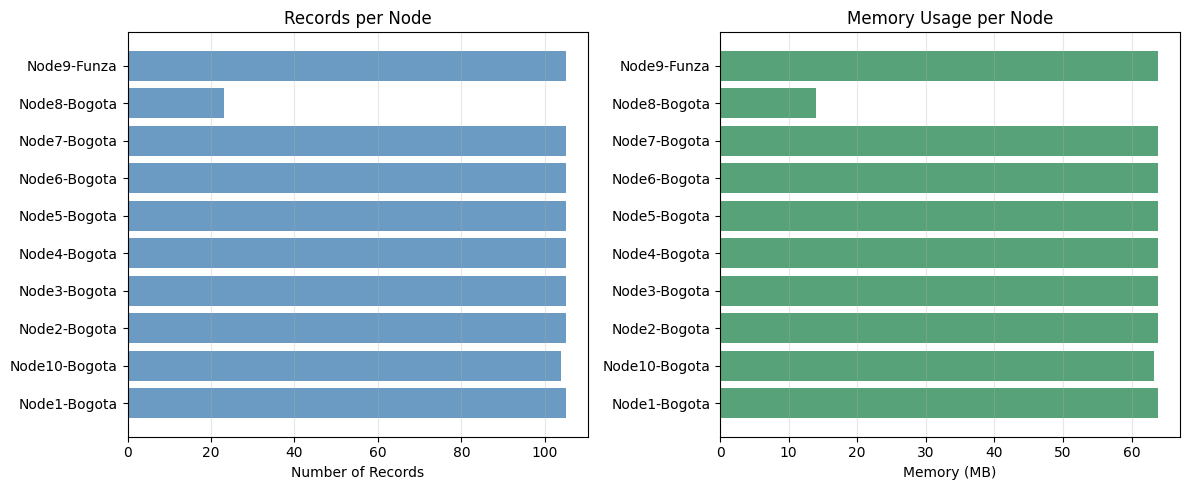

In [11]:
# ── Record Integrity Visualization ─────────────────────────────────────

if datos_nodos and len(datos_nodos) > 1:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    node_labels = [n.split('/')[-1] for n in node_shapes.keys()]
    row_counts = [s['rows'] for s in node_shapes.values()]
    plt.barh(node_labels, row_counts, color='steelblue', alpha=0.8)
    plt.xlabel("Number of Records")
    plt.title("Records per Node")
    plt.grid(axis='x', alpha=0.3)

# ── Memory Usage Visualization ─────────────────────────────────────
    plt.subplot(1, 2, 2)
    memory_vals = [df.memory_usage(deep=True).sum() / (1024**2) for df in datos_nodos.values()]
    plt.barh(node_labels, memory_vals, color='seagreen', alpha=0.8)
    plt.xlabel("Memory (MB)")
    plt.title("Memory Usage per Node")
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [15]:
if datos_nodos:  # ← Fixed typo
    data_summary = {
        'timestamp': pd.Timestamp.now().isoformat(),
        'n_nodes': len(datos_nodos),
        'total_records': total_rows,
        'total_memory_mb': total_memory_bytes / (1024**2),
        'node_shapes': node_shapes,
        'safe_row_range': (global_min, global_max),
        'columns': list(first_node.columns),
        'excluded_nodes': list(EXCLUDE),
        'load_errors': load_errors,
    }

    print(f" Summary dictionary stored in 'data_summary'")
    print(f"    timestamp → {data_summary['timestamp']}")
    print(f"    n_nodes → {data_summary['n_nodes']}")
    print(f"    excluded_nodes → {data_summary['excluded_nodes']}")
    print(f"    load_errors → {data_summary['load_errors']}")
    print(f"    safe_row_range → {data_summary['safe_row_range']}")
    row_counts = [s['rows'] for s in node_shapes.values()]
    mode_rows = pd.Series(row_counts).mode().iloc[0]
    outlier_nodes = {k: v['rows'] for k, v in node_shapes.items()
                 if v['rows'] < mode_rows * 0.5}
    if outlier_nodes:
        print(f"      • Row-count outliers detected: {outlier_nodes}")
        print(f"      • safe_row_range is capped to {global_max} — consider excluding outlier nodes.")
    
    print(f"      • Mode of rows: {mode_rows}")
    print(f"    Value range → [{pxx_array.min():.2f}, {pxx_array.max():.2f}]")
else:
    data_summary = {}
    print("  data_summary is empty — no nodes were loaded successfully.")

 Summary dictionary stored in 'data_summary'
    timestamp → 2026-03-18T22:14:13.396437
    n_nodes → 10
    excluded_nodes → []
    load_errors → []
    safe_row_range → (0, 22)
      • Row-count outliers detected: {'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota': 23}
      • safe_row_range is capped to 22 — consider excluding outlier nodes.
      • Mode of rows: 105
    Value range → [-24.57, 3.17]


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>